# Thesis — consolidated post-review analysis

This notebook reproduces every analysis added during the review pass:

1. **Clean (de-contaminated) results** — separate the RQ1 / RQ2-A / RQ2-B LODO pools, drop the duplicate run, and recompute all tables, ablation, statistical tests and correlations.
2. **SciBERT homogeneity test** — tests the "Eggmann is too lexically homogeneous for SciBERT" claim across all 10 RQ1 datasets.
3. **Citation-subgraph fragmentation test** — tests the "Eggmann's relevant papers form a fragmented subgraph" claim (it does **not**).

Run top to bottom. Set `THESIS_ROOT` below if you run it from outside the thesis folder.


## 0. Setup

In [2]:
from pathlib import Path
import csv, re, json, numpy as np
from collections import defaultdict
csv.field_size_limit(10**9)
np.random.seed(42)

THESIS_ROOT = Path.cwd().parent
WEEK4 = THESIS_ROOT / "Week 4 - Ablation Study"
WEEK5 = THESIS_ROOT / "Week 5 - Final Results"
RESULTS_CSV = WEEK5 / "results" / "all_results.csv"
assert RESULTS_CSV.exists(), f"Set THESIS_ROOT correctly; not found: {RESULTS_CSV}"
print("Thesis root:", THESIS_ROOT)


Thesis root: /Users/belizpekkan/Library/Mobile Documents/com~apple~CloudDocs/2 AREAS/university/Master/Thesis


## 1. Clean (de-contaminated) results

`all_results.csv` concatenated three experiments with no `pool` column, plus an exact duplicate of the RQ1 run:

| rows | what |
|---|---|
| RQ1 pool | 10 datasets × 5 conditions × 5 seeds |
| RQ2-A (osteoarthritis) | 6 datasets |
| RQ2-B (PTSD/trauma) | 6 datasets |
| duplicate | byte-identical re-run of RQ1 → dropped |

The original tables were built with `groupby(['dataset','model']).mean()` over **all** rows, so the four datasets in two pools (Pijls, Pinos-Cisneros, Tumkaya, Rinne) were averaged across pools + duplicates. Below we assign pools by contiguous run-block, drop the duplicate, relabel models to the thesis convention (C2a = SciBERT+SVM, C2b = SciBERT+LR), and recompute everything cleanly.

In [3]:
rows=list(csv.DictReader(open(RESULTS_CSV)))
# contiguous (dataset,model) run-blocks, in file order
blocks=[]; i=0
while i<len(rows):
    ds,mdl=rows[i]['dataset'],rows[i]['model']; j=i
    while j<len(rows) and rows[j]['dataset']==ds and rows[j]['model']==mdl: j+=1
    blocks.append((i,j)); i=j
def pool_of(b):   # block index -> pool (validated against the run log)
    return 'RQ1' if b<=49 else 'RQ2_A_osteoarthritis' if b<=79 else 'RQ2_B_ptsd' if b<=109 else 'DUP'
RELABEL={'C1_TFIDF_SVM':'C1_TFIDF_SVM','C2b_SciBERT_SVM':'C2a_SciBERT_SVM',
         'C2a_SciBERT_LR':'C2b_SciBERT_LR','C3_GAT_only':'C3_GAT_only','C4_GNN_NLP_Fusion':'C4_GNN_NLP_Fusion'}
clean=[]
for bidx,(s,e) in enumerate(blocks):
    p=pool_of(bidx)
    if p=='DUP': continue
    for r in rows[s:e]:
        clean.append({'pool':p,'dataset':r['dataset'],'model':RELABEL[r['model']],
                      'seed':r['seed'],'nl':float(r['nl']),'wss95':float(r['wss95'])})
out=WEEK5/"results"/"all_results_CLEAN.csv"
with open(out,'w',newline='') as f:
    w=csv.DictWriter(f,fieldnames=['pool','dataset','model','seed','nl','wss95']); w.writeheader()
    for r in clean: w.writerow(r)
from collections import Counter
print("clean rows:",len(clean),"| pools:",dict(Counter(r['pool'] for r in clean)))
print("written:",out)

clean rows: 550 | pools: {'RQ1': 250, 'RQ2_A_osteoarthritis': 150, 'RQ2_B_ptsd': 150}
written: /Users/belizpekkan/Library/Mobile Documents/com~apple~CloudDocs/2 AREAS/university/Master/Thesis/Week 5 - Final Results/results/all_results_CLEAN.csv


In [4]:
ORDER=['C1_TFIDF_SVM','C2a_SciBERT_SVM','C2b_SciBERT_LR','C3_GAT_only','C4_GNN_NLP_Fusion']
DISP={'C1_TFIDF_SVM':'C1 TF-IDF+SVM','C2a_SciBERT_SVM':'C2a SciBERT+SVM','C2b_SciBERT_LR':'C2b SciBERT+LR','C3_GAT_only':'C3 GAT-only','C4_GNN_NLP_Fusion':'C4 Fusion'}
RQ1=['Greca_2023','Pijls_2018','Tumkaya_2018','Rinne_2021','Pinos-Cisneros_2023','Abgaz_2023','Erer_2015','Demirkaya_2015','Leenaars_2020','Eggmann_2023']
RQ2_A=['Pijls_2018','Cozim-Melges_2024','Pinos-Cisneros_2023','van_der_Valk_2021','Meijboom_2021','Tektonidou_2019']
RQ2_B=['Tumkaya_2018','Rinne_2021','Donners_2021','Smid_2019','Boersma-van_Dam_2024','Oud_2018']
def mean_nl(pool,ds,m):
    v=[r['nl'] for r in clean if r['pool']==pool and r['dataset']==ds and r['model']==m]
    return sum(v)/len(v)
tab={ds:[mean_nl('RQ1',ds,m) for m in ORDER] for ds in RQ1}
print("RQ1 per-dataset mean NL (clean):")
print(f"{'dataset':<22}"+''.join(f'{DISP[m]:>16}' for m in ORDER))
for ds in RQ1: print(f"{ds:<22}"+''.join(f'{x:>16.3f}' for x in tab[ds]))
print(f"{'POOL MEAN':<22}"+''.join(f'{sum(tab[d][k] for d in RQ1)/10:>16.3f}' for k in range(5)))

RQ1 per-dataset mean NL (clean):
dataset                  C1 TF-IDF+SVM C2a SciBERT+SVM  C2b SciBERT+LR     C3 GAT-only       C4 Fusion
Greca_2023                       0.456           0.361           0.343           0.278           0.279
Pijls_2018                       0.297           0.307           0.307           0.395           0.252
Tumkaya_2018                     0.578           0.294           0.347           0.315           0.355
Rinne_2021                       0.336           0.348           0.329           0.364           0.319
Pinos-Cisneros_2023              0.425           0.319           0.327           0.373           0.319
Abgaz_2023                       0.335           0.295           0.241           0.216           0.210
Erer_2015                        0.343           0.370           0.311           0.658           0.208
Demirkaya_2015                   0.043           0.067           0.036           0.376           0.174
Leenaars_2020                    0.207  

In [5]:
import statistics
print("RQ1 condition summary (clean):")
wins=defaultdict(int)
for ds in RQ1:
    vals={m:tab[ds][k] for k,m in enumerate(ORDER)}; wins[min(vals,key=vals.get)]+=1
for m in ORDER:
    col=[tab[ds][ORDER.index(m)] for ds in RQ1]
    print(f"  {DISP[m]:<18} mean={sum(col)/10:.3f}  sd={statistics.pstdev(col):.3f}  median={statistics.median(col):.3f}  rank1={wins[m]}")

RQ1 condition summary (clean):
  C1 TF-IDF+SVM      mean=0.338  sd=0.136  median=0.340  rank1=1
  C2a SciBERT+SVM    mean=0.293  sd=0.090  median=0.313  rank1=3
  C2b SciBERT+LR     mean=0.291  sd=0.107  median=0.319  rank1=1
  C3 GAT-only        mean=0.369  sd=0.110  median=0.368  rank1=1
  C4 Fusion          mean=0.282  sd=0.092  median=0.265  rank1=4


In [6]:
from scipy.stats import friedmanchisquare, wilcoxon, spearmanr
def step(a,b):
    av=[tab[d][ORDER.index(a)] for d in RQ1]; bv=[tab[d][ORDER.index(b)] for d in RQ1]
    d=sum(bv)/10-sum(av)/10; W,p=wilcoxon(av,bv); r=1-4*W/(10*11)
    return d,p,r
print("Ablation decomposition (clean, paired Wilcoxon, N=10):")
for name,a,b in [('C1->C2a feature (TFIDF->SciBERT)','C1_TFIDF_SVM','C2a_SciBERT_SVM'),
                 ('C2a->C2b classifier','C2a_SciBERT_SVM','C2b_SciBERT_LR'),
                 ('C2b->C4 graph fusion','C2b_SciBERT_LR','C4_GNN_NLP_Fusion'),
                 ('C1->C4 total','C1_TFIDF_SVM','C4_GNN_NLP_Fusion')]:
    d,p,r=step(a,b); print(f"  {name:<34} dNL={d:+.3f}  p={p:.3f}  r={r:.3f}")
groups=[[tab[d][ORDER.index(m)] for d in RQ1] for m in ORDER]
chi,p=friedmanchisquare(*groups); print(f"\nFriedman omnibus: chi2(4)={chi:.3f}, p={p:.3f}")
c4=[tab[d][ORDER.index('C4_GNN_NLP_Fusion')] for d in RQ1]
print("Pairwise Wilcoxon vs C4 (raw p):")
for m in [x for x in ORDER if x!='C4_GNN_NLP_Fusion']:
    mv=[tab[d][ORDER.index(m)] for d in RQ1]; W,pr=wilcoxon(c4,mv); r=1-4*W/(10*11)
    print(f"  C4 vs {DISP[m]:<16} W={W:.1f}  p={pr:.3f}  r={r:.3f}  dNL={sum(c4)/10-sum(mv)/10:+.3f}")

Ablation decomposition (clean, paired Wilcoxon, N=10):
  C1->C2a feature (TFIDF->SciBERT)   dNL=-0.045  p=0.432  r=0.309
  C2a->C2b classifier                dNL=-0.002  p=0.695  r=0.164
  C2b->C4 graph fusion               dNL=-0.009  p=0.375  r=0.345
  C1->C4 total                       dNL=-0.056  p=0.193  r=0.491

Friedman omnibus: chi2(4)=5.688, p=0.224
Pairwise Wilcoxon vs C4 (raw p):
  C4 vs C1 TF-IDF+SVM    W=14.0  p=0.193  r=0.491  dNL=-0.056
  C4 vs C2a SciBERT+SVM  W=20.0  p=0.767  r=0.273  dNL=-0.011
  C4 vs C2b SciBERT+LR   W=18.0  p=0.375  r=0.345  dNL=-0.009
  C4 vs C3 GAT-only      W=10.0  p=0.084  r=0.636  dNL=-0.087


In [7]:
print("RQ2 within-domain tables (clean, domain pools only):")
for name,pl,pool_ds in [('Osteoarthritis','RQ2_A_osteoarthritis',RQ2_A),('PTSD/Trauma','RQ2_B_ptsd',RQ2_B)]:
    print(f"-- {name} (N={len(pool_ds)})")
    for m in ORDER:
        col=[mean_nl(pl,ds,m) for ds in pool_ds]
        print(f"   {DISP[m]:<18} mean={sum(col)/len(col):.3f}  sd={statistics.pstdev(col):.3f}")
    g=[[mean_nl(pl,ds,m) for ds in pool_ds] for m in ORDER]
    chi,p=friedmanchisquare(*g); print(f"   Friedman chi2(4)={chi:.3f}  p={p:.3f}")

uniq=list(dict.fromkeys(RQ1+RQ2_A+RQ2_B))
def cval(ds,m):
    pl='RQ1' if ds in RQ1 else 'RQ2_A_osteoarthritis' if ds in RQ2_A else 'RQ2_B_ptsd'
    return mean_nl(pl,ds,m)
c1=[cval(d,'C1_TFIDF_SVM') for d in uniq]; c4u=[cval(d,'C4_GNN_NLP_Fusion') for d in uniq]
print(f"\nrho(C1 NL, C4 NL) over {len(uniq)} unique datasets = {spearmanr(c1,c4u)[0]:.3f} (p={spearmanr(c1,c4u)[1]:.4f})")

RQ2 within-domain tables (clean, domain pools only):
-- Osteoarthritis (N=6)
   C1 TF-IDF+SVM      mean=0.309  sd=0.072
   C2a SciBERT+SVM    mean=0.343  sd=0.113
   C2b SciBERT+LR     mean=0.328  sd=0.115
   C3 GAT-only        mean=0.368  sd=0.128
   C4 Fusion          mean=0.297  sd=0.101
   Friedman chi2(4)=5.200  p=0.267
-- PTSD/Trauma (N=6)
   C1 TF-IDF+SVM      mean=0.399  sd=0.100
   C2a SciBERT+SVM    mean=0.381  sd=0.067
   C2b SciBERT+LR     mean=0.358  sd=0.091
   C3 GAT-only        mean=0.331  sd=0.111
   C4 Fusion          mean=0.297  sd=0.076
   Friedman chi2(4)=11.333  p=0.023

rho(C1 NL, C4 NL) over 18 unique datasets = 0.705 (p=0.0011)


## 2. SciBERT homogeneity test (text side)

Loads the cached frozen-SciBERT `[CLS]` embeddings, L2-normalises, and computes per dataset: **overall homogeneity** (mean pairwise cosine over all records) and **positive-class separation** (mean intra-relevant − mean relevant-to-irrelevant cosine). Eggmann should be the most homogeneous / least separable if the claim holds.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
def load_emb(ds):
    emb=np.load(WEEK4/"cache"/"scibert_embeddings"/f"{ds}_scibert.npy").astype(np.float64)
    rws=list(csv.reader(open(WEEK4/"data"/f"{ds}.csv")))
    h=rws[0]; li=h.index('label_included')
    y=np.array([int(float(r[li])) if r[li] not in('','nan') else 0 for r in rws[1:]])
    n=min(len(emb),len(y)); return emb[:n], y[:n]
def l2(X):
    nr=np.linalg.norm(X,axis=1,keepdims=True); nr[nr==0]=1; return X/nr
def pair(D):
    if len(D)<2: return np.nan
    S=D@D.T; iu=np.triu_indices(len(D),1); return float(S[iu].mean())
def sub(idx,c): return np.random.choice(idx,c,replace=False) if len(idx)>c else idx

hom={}
print(f"{'dataset':<20}{'n':>6}{'rel':>5}{'overallHom':>11}{'posSeparation':>14}")
for ds in RQ1:
    emb,y=load_emb(ds); Xn=l2(emb); pos=np.where(y==1)[0]; neg=np.where(y==0)[0]
    overall=pair(Xn[sub(np.arange(len(y)),1000)]); intra=pair(Xn[sub(pos,400)])
    relirr=float((Xn[sub(pos,500)]@Xn[sub(neg,1000)].T).mean())
    hom[ds]=dict(n=int(len(y)),rel=int(y.sum()),overall=overall,sep=intra-relirr)
    print(f"{ds:<20}{len(y):>6}{int(y.sum()):>5}{overall:>11.3f}{intra-relirr:>14.3f}")
e=hom['Eggmann_2023']
print(f"\nEggmann overall homogeneity rank: {sum(hom[d]['overall']<e['overall'] for d in RQ1)+1}/10 (10=highest)")
print(f"Eggmann positive separation rank: {sum(hom[d]['sep']<e['sep'] for d in RQ1)+1}/10 (1=lowest)")

dataset                  n  rel overallHom posSeparation
Greca_2023            1163   78      0.699         0.068
Pijls_2018            1004   52      0.737         0.042
Tumkaya_2018           721   52      0.731         0.039


/var/folders/mv/lz0zg3211sq0hq6smvvclknh0000gn/T/ipykernel_10801/1895903398.py:12: RuntimeWarning: divide by zero encountered in matmul
  S=D@D.T; iu=np.triu_indices(len(D),1); return float(S[iu].mean())
/var/folders/mv/lz0zg3211sq0hq6smvvclknh0000gn/T/ipykernel_10801/1895903398.py:12: RuntimeWarning: overflow encountered in matmul
  S=D@D.T; iu=np.triu_indices(len(D),1); return float(S[iu].mean())
/var/folders/mv/lz0zg3211sq0hq6smvvclknh0000gn/T/ipykernel_10801/1895903398.py:12: RuntimeWarning: invalid value encountered in matmul
  S=D@D.T; iu=np.triu_indices(len(D),1); return float(S[iu].mean())
/var/folders/mv/lz0zg3211sq0hq6smvvclknh0000gn/T/ipykernel_10801/1895903398.py:20: RuntimeWarning: divide by zero encountered in matmul
  relirr=float((Xn[sub(pos,500)]@Xn[sub(neg,1000)].T).mean())
/var/folders/mv/lz0zg3211sq0hq6smvvclknh0000gn/T/ipykernel_10801/1895903398.py:20: RuntimeWarning: overflow encountered in matmul
  relirr=float((Xn[sub(pos,500)]@Xn[sub(neg,1000)].T).mean())
/var/

Rinne_2021            1765  407      0.667         0.084
Pinos-Cisneros_2023    228   54      0.705         0.021
Abgaz_2023             733   34      0.711         0.081
Erer_2015             1249    2      0.692         0.096
Demirkaya_2015        1032    7      0.664         0.044
Leenaars_2020         7394  590      0.690         0.077
Eggmann_2023           828   23      0.786         0.016

Eggmann overall homogeneity rank: 10/10 (10=highest)
Eggmann positive separation rank: 1/10 (1=lowest)


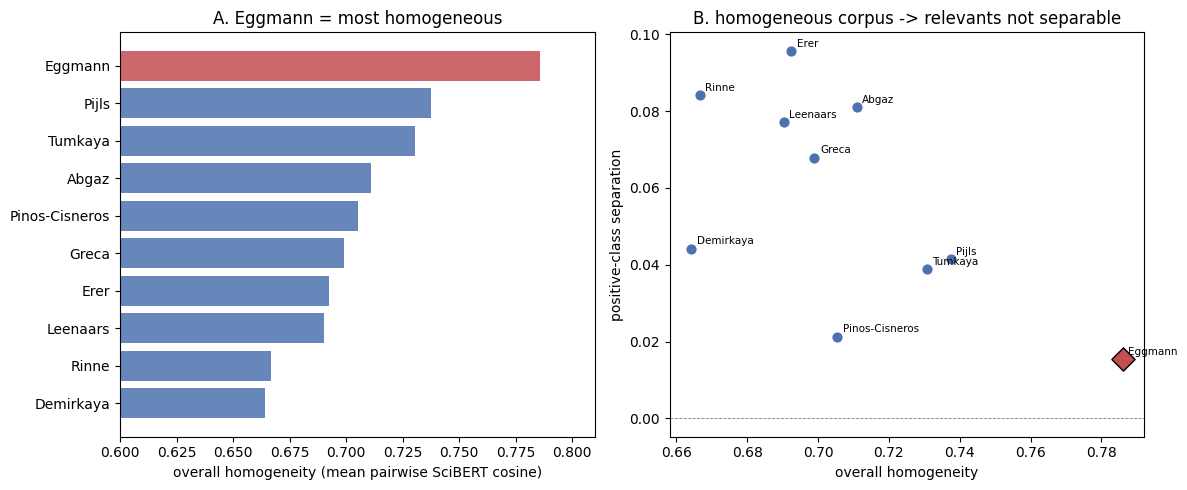

In [14]:
import matplotlib.pyplot as plt
DSk=list(hom); short={d:d.split('_')[0] for d in DSk}
ov=np.array([hom[d]['overall'] for d in DSk]); sp=np.array([hom[d]['sep'] for d in DSk])
egg=np.array([d=='Eggmann_2023' for d in DSk])
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
o=np.argsort(ov)
a1.barh(range(len(DSk)),ov[o],color=['#C44E52' if egg[o][i] else '#4C72B0' for i in range(len(DSk))],alpha=.85)
a1.set_yticks(range(len(DSk))); a1.set_yticklabels([short[DSk[i]] for i in o]); a1.set_xlim(.6,.81)
a1.set_xlabel('overall homogeneity (mean pairwise SciBERT cosine)'); a1.set_title('A. Eggmann = most homogeneous')
a2.scatter(ov[~egg],sp[~egg],s=70,color='#4C72B0',edgecolors='white',zorder=3)
a2.scatter(ov[egg],sp[egg],s=140,color='#C44E52',marker='D',edgecolors='black',zorder=4)
for d in DSk: a2.annotate(short[d],(hom[d]['overall'],hom[d]['sep']),fontsize=7.5,xytext=(4,3),textcoords='offset points')
a2.axhline(0,color='grey',lw=.6,ls='--'); a2.set_xlabel('overall homogeneity'); a2.set_ylabel('positive-class separation')
a2.set_title('B. homogeneous corpus -> relevants not separable')
plt.tight_layout(); plt.savefig(WEEK5/"fig_eggmann_homogeneity.png",dpi=200,bbox_inches='tight'); plt.show()

## 3. Citation-subgraph fragmentation test (graph side)

Rebuilds the within-dataset directed citation graphs from `referenced_works` (validated against the logged C3 edge counts), then measures fragmentation of the **relevant** subgraph. Tests whether Eggmann's relevant papers are scattered across sub-fields (the draft's claim). **Note the case mismatch:** `openalex_id` uses lowercase `w`, `referenced_works` uppercase `W` — both are normalised below.

In [17]:
import networkx as nx
EXPECT={'Greca_2023':3240,'Pijls_2018':5875,'Tumkaya_2018':7360,'Rinne_2021':4071,'Pinos-Cisneros_2023':347,
        'Abgaz_2023':2538,'Erer_2015':6107,'Demirkaya_2015':4119,'Leenaars_2020':51273,'Eggmann_2023':2326}
def wid(s):
    m=re.search(r'[Ww](\d+)', s or ''); return 'W'+m.group(1) if m else None
def wids(s):
    return ['W'+d for d in re.findall(r'[Ww](\d+)', s or '')]
graph={}
print(f"{'dataset':<20}{'edges':>7}{'exp':>7}{'nRel':>6}{'lccFrac':>9}{'#comp':>7}{'isoFrac':>9}{'clust':>7}")
for ds in RQ1:
    rws=list(csv.reader(open(WEEK4/"data"/f"{ds}.csv")))
    h=rws[0]; oi=h.index('openalex_id'); li=h.index('label_included'); ri=h.index('referenced_works')
    nodes={}
    for r in rws[1:]:
        nid=wid(r[oi])
        if nid: nodes[nid]=int(float(r[li])) if r[li] not in('','nan') else 0
    G=nx.DiGraph(); G.add_nodes_from(nodes)
    for r in rws[1:]:
        u=wid(r[oi])
        if u is None: continue
        for v in wids(r[ri]):
            if v in nodes and v!=u: G.add_edge(u,v)
    rel=[n for n in G if nodes[n]==1]; Gr=G.subgraph(rel).to_undirected()
    comps=sorted(nx.connected_components(Gr),key=len,reverse=True)
    lcc=len(comps[0])/len(rel) if rel else float('nan')
    iso=sum(1 for n in Gr if Gr.degree(n)==0)/len(rel) if rel else float('nan')
    clust=nx.average_clustering(Gr) if len(rel)>2 else 0.0
    graph[ds]=dict(rel=len(rel),lcc=lcc,ncomp=len(comps),iso=iso,clust=clust,Gr=Gr)
    print(f"{ds:<20}{G.number_of_edges():>7}{EXPECT[ds]:>7}{len(rel):>6}{lcc:>9.2f}{len(comps):>7}{iso:>9.2f}{clust:>7.3f}")
print("\n-> Eggmann: 22/23 relevant papers in ONE component (lcc=0.96) -> NOT fragmented; hypothesis refuted.")

dataset               edges    exp  nRel  lccFrac  #comp  isoFrac  clust
Greca_2023             3229   3240    78     0.76     19     0.22  0.242
Pijls_2018             5872   5875    52     0.90      6     0.10  0.295
Tumkaya_2018           7358   7360    52     1.00      1     0.00  0.465
Rinne_2021             4064   4071   407     0.67    125     0.29  0.080
Pinos-Cisneros_2023     345    347    54     0.59     19     0.28  0.059
Abgaz_2023             2536   2538    34     0.88      4     0.06  0.415
Erer_2015              6103   6107     2     1.00      1     0.00  0.000
Demirkaya_2015         4115   4119     7     0.86      2     0.14  0.543
Leenaars_2020         51230  51273   590     0.76    138     0.22  0.174
Eggmann_2023           2324   2326    23     0.96      2     0.04  0.311

-> Eggmann: 22/23 relevant papers in ONE component (lcc=0.96) -> NOT fragmented; hypothesis refuted.


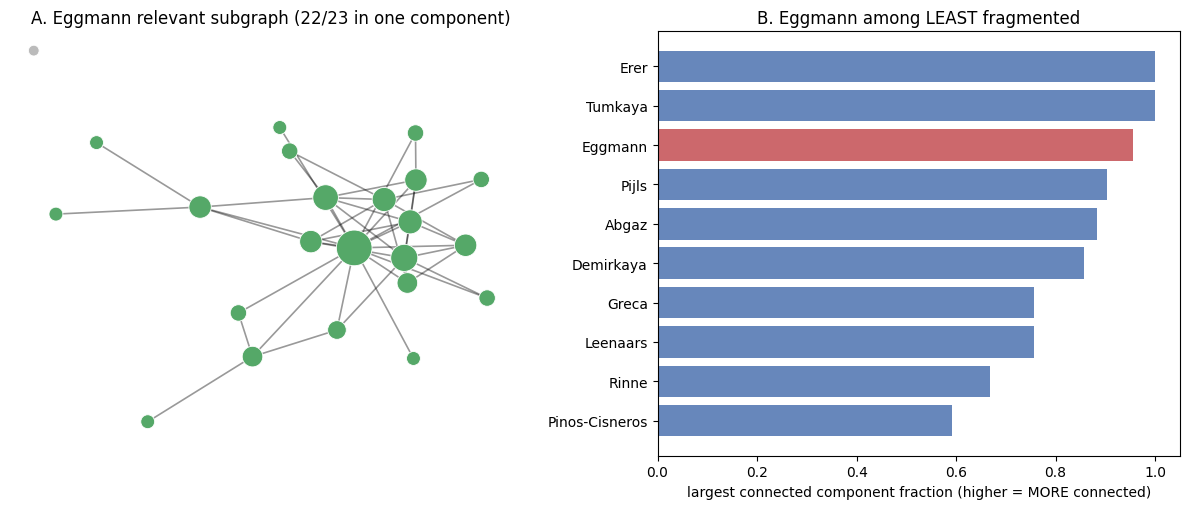

In [18]:
Gr=graph['Eggmann_2023']['Gr']
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5.2))
pos=nx.spring_layout(Gr,seed=42,k=0.6); giant=max(nx.connected_components(Gr),key=len)
deg=dict(Gr.degree())
nx.draw_networkx_edges(Gr,pos,ax=a1,alpha=.4,width=1.2)
nx.draw_networkx_nodes(Gr,pos,ax=a1,node_color=['#55A868' if n in giant else '#BBB' for n in Gr],
    node_size=[60+40*deg[n] for n in Gr],edgecolors='white',linewidths=.6)
a1.set_title('A. Eggmann relevant subgraph (22/23 in one component)'); a1.axis('off')
DSk=list(graph); short={d:d.split('_')[0] for d in DSk}
lcc=np.array([graph[d]['lcc'] for d in DSk]); o=np.argsort(lcc); egg=np.array([d=='Eggmann_2023' for d in DSk])
a2.barh(range(len(DSk)),lcc[o],color=['#C44E52' if egg[o][i] else '#4C72B0' for i in range(len(DSk))],alpha=.85)
a2.set_yticks(range(len(DSk))); a2.set_yticklabels([short[DSk[i]] for i in o]); a2.set_xlim(0,1.05)
a2.set_xlabel('largest connected component fraction (higher = MORE connected)')
a2.set_title('B. Eggmann among LEAST fragmented')
plt.tight_layout(); plt.savefig(WEEK5/"fig_eggmann_graph.png",dpi=200,bbox_inches='tight'); plt.show()

## 3b. Demirkaya & the failure-case synthesis

Tests the draft's "graph fusion needs a minimum number of relevant nodes" explanation for Demirkaya. Uses the clean RQ1 means (section 1) and the relevant counts (section 2). Result: the fusion effect is uncorrelated with positive-class size; Demirkaya regresses because its text baseline is already saturated.

dataset               nRel C2b(text)     C4 fusionDelta
Erer_2015                2     0.311  0.208      -0.104
Greca_2023              78     0.343  0.279      -0.065
Pijls_2018              52     0.307  0.252      -0.055
Abgaz_2023              34     0.241  0.210      -0.032
Rinne_2021             407     0.329  0.319      -0.010
Pinos-Cisneros_2023     54     0.327  0.319      -0.008
Leenaars_2020          590     0.204  0.203      -0.001
Tumkaya_2018            52     0.347  0.355      +0.008
Eggmann_2023            23     0.467  0.501      +0.034
Demirkaya_2015           7     0.036  0.174      +0.138

Spearman(fusion delta, #relevant) = -0.061 (p=0.868)
-> uncorrelated; Erer (2 relevant) gains most, Demirkaya (7) regresses most -> 'min nodes' refuted.
-> Demirkaya text NL 0.036 is the pool minimum (next 0.297): a ceiling effect, not a node-count effect.


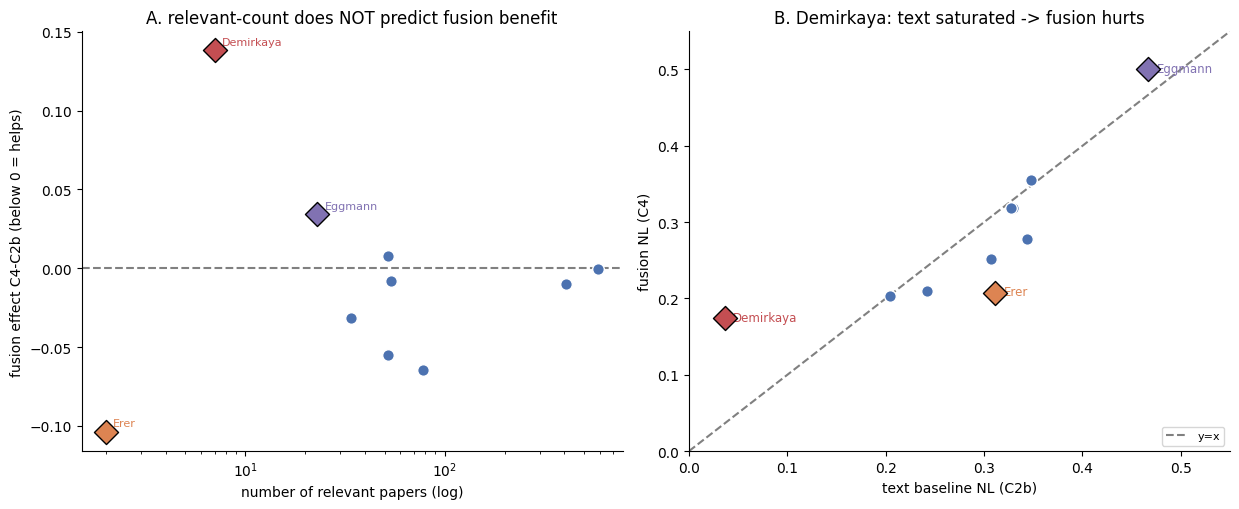

In [19]:
from scipy.stats import spearmanr
C1d={d:mean_nl('RQ1',d,'C1_TFIDF_SVM') for d in RQ1}
C2bd={d:mean_nl('RQ1',d,'C2b_SciBERT_LR') for d in RQ1}
C4d={d:mean_nl('RQ1',d,'C4_GNN_NLP_Fusion') for d in RQ1}
nrel={d:hom[d]['rel'] for d in RQ1}
dfus={d:C4d[d]-C2bd[d] for d in RQ1}
print(f"{'dataset':<20}{'nRel':>6}{'C2b(text)':>10}{'C4':>7}{'fusionDelta':>12}")
for d in sorted(RQ1,key=lambda x:dfus[x]):
    print(f"{d:<20}{nrel[d]:>6}{C2bd[d]:>10.3f}{C4d[d]:>7.3f}{dfus[d]:>+12.3f}")
print("\nSpearman(fusion delta, #relevant) = %.3f (p=%.3f)"%spearmanr([nrel[d] for d in RQ1],[dfus[d] for d in RQ1]))
print("-> uncorrelated; Erer (2 relevant) gains most, Demirkaya (7) regresses most -> 'min nodes' refuted.")
print("-> Demirkaya text NL 0.036 is the pool minimum (next 0.297): a ceiling effect, not a node-count effect.")

hi={'Demirkaya_2015':'#C44E52','Erer_2015':'#DD8452','Eggmann_2023':'#8172B2'}
shortd={d:d.split('_')[0] for d in RQ1}
col=lambda d:hi.get(d,'#4C72B0'); sz=lambda d:150 if d in hi else 70
fig,(a1,a2)=plt.subplots(1,2,figsize=(12.5,5.2))
for d in RQ1:
    a1.scatter(nrel[d],dfus[d],s=sz(d),color=col(d),marker='D' if d in hi else 'o',
               edgecolors='black' if d in hi else 'white',zorder=4 if d in hi else 3)
    if d in hi or nrel[d]<10: a1.annotate(shortd[d],(nrel[d],dfus[d]),fontsize=8,xytext=(5,4),textcoords='offset points',color=col(d))
a1.axhline(0,color='grey',ls='--'); a1.set_xscale('log')
a1.set_xlabel('number of relevant papers (log)'); a1.set_ylabel('fusion effect C4-C2b (below 0 = helps)')
a1.set_title('A. relevant-count does NOT predict fusion benefit')
lim=[0,0.55]; a2.plot(lim,lim,'--',color='grey',label='y=x')
for d in RQ1:
    a2.scatter(C2bd[d],C4d[d],s=sz(d),color=col(d),marker='D' if d in hi else 'o',
               edgecolors='black' if d in hi else 'white',zorder=4 if d in hi else 3)
    if d in hi: a2.annotate(shortd[d],(C2bd[d],C4d[d]),fontsize=8.5,xytext=(6,-2),textcoords='offset points',color=col(d))
a2.set_xlim(lim); a2.set_ylim(lim); a2.set_xlabel('text baseline NL (C2b)'); a2.set_ylabel('fusion NL (C4)')
a2.set_title('B. Demirkaya: text saturated -> fusion hurts'); a2.legend(fontsize=8,loc='lower right')
for a in (a1,a2): a.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(WEEK5/"fig_demirkaya_failurecases.png",dpi=200,bbox_inches='tight'); plt.show()

## 4. Summary

- **Clean results:** conclusions unchanged (C4 best; RQ1 Friedman ns), but per-dataset RQ1 values for the 4 overlap datasets, the rank-1 count (5/10 → **4/10**), the graph-fusion share (~25% → **~16%**), and the RQ2 numbers (PTSD Friedman now **p=0.023**) all update. Use `all_results_CLEAN.csv`.
- **Homogeneity test (text):** Eggmann is the **most homogeneous** corpus (0.786) with the **least separable** relevant class (0.016) → backs the "TF-IDF beats SciBERT here" claim.
- **Fragmentation test (graph):** Eggmann's relevant subgraph is **cohesive** (22/23 in one component) → **refutes** the "fragmented subgraph" claim; remove that sentence. Eggmann instead illustrates the central finding (graph can't rescue a text-dominated failure).
- **Demirkaya / synthesis:** fusion effect is **uncorrelated with positive-class size** (ρ=−0.06, p=0.87; Erer with 2 relevant gains most) → the "minimum relevant nodes" claim is **refuted**. Demirkaya regresses because its text baseline (0.036) is already saturated. All three boundary cases reduce to one principle: graph fusion helps only when text is informative-but-imperfect, and regresses at both the saturated end (Demirkaya) and the failed-text end (Eggmann).


## 5. Appendix C — Within-domain citation density vs fusion benefit

Verifies the Discussion claim about citation density. For each of the 12 within-domain RQ2
datasets we rebuild the full-corpus citation graph and compute its density `E / [N(N-1)]`,
then relate density to (a) C3 GAT-only performance and (b) the fusion benefit `C2b - C4`.

Result: PTSD/trauma graphs are **not** significantly denser than osteoarthritis graphs
(Mann-Whitney p = 0.82), and GAT-only NL is **uncorrelated** with density (rho = 0.00).
The real effect is at the dataset level: the **fusion benefit rises with density**
(Spearman rho = 0.70, p = 0.011). Generates the two Appendix C figures.


In [20]:
# --- C.1  build full-corpus citation graphs for the 12 within-domain datasets ---
import networkx as nx
from scipy.stats import spearmanr, mannwhitneyu

RQ2_A = ['Pijls_2018','Cozim-Melges_2024','Pinos-Cisneros_2023','van_der_Valk_2021','Meijboom_2021','Tektonidou_2019']
RQ2_B = ['Tumkaya_2018','Rinne_2021','Donners_2021','Smid_2019','Boersma-van_Dam_2024','Oud_2018']
DOMAIN = {**{d:'Osteoarthritis' for d in RQ2_A}, **{d:'PTSD/trauma' for d in RQ2_B}}

def density_row(ds):
    rr = list(csv.reader(open(WEEK4/"data"/f"{ds}.csv")))
    h = rr[0]; oi = h.index('openalex_id'); ri = h.index('referenced_works')
    nodes = set(filter(None, (wid(r[oi]) for r in rr[1:])))
    G = nx.DiGraph(); G.add_nodes_from(nodes)
    for r in rr[1:]:
        u = wid(r[oi])
        if u is None: continue
        for v in wids(r[ri]):
            if v in nodes and v != u: G.add_edge(u, v)
    pool = 'RQ2_A_osteoarthritis' if ds in RQ2_A else 'RQ2_B_ptsd'
    return dict(domain=DOMAIN[ds], dataset=ds, N=G.number_of_nodes(), edges=G.number_of_edges(),
                density=nx.density(G), mean_degree=G.number_of_edges()/G.number_of_nodes(),
                pct_connected=100*sum(1 for n in G if G.out_degree(n) > 0)/G.number_of_nodes(),
                C3_nl=mean_nl(pool, ds, 'C3_GAT_only'),
                fusion_benefit=mean_nl(pool, ds, 'C2b_SciBERT_LR') - mean_nl(pool, ds, 'C4_GNN_NLP_Fusion'))

cdens = sorted((density_row(ds) for ds in RQ2_A+RQ2_B), key=lambda r: r['density'])
print(f"{'domain':16}{'dataset':22}{'N':>6}{'edges':>7}{'density':>10}{'deg':>7}{'%conn':>7}{'C3_nl':>7}{'fus_ben':>9}")
for r in cdens:
    print(f"{r['domain']:16}{r['dataset']:22}{r['N']:>6}{r['edges']:>7}{r['density']:>10.6f}"
          f"{r['mean_degree']:>7.2f}{r['pct_connected']:>7.1f}{r['C3_nl']:>7.3f}{r['fusion_benefit']:>+9.3f}")


domain          dataset                    N  edges   density    deg  %conn  C3_nl  fus_ben
Osteoarthritis  Tektonidou_2019         5653  37317  0.001168   6.60   65.3  0.331   +0.001
PTSD/trauma     Rinne_2021              1765   4064  0.001305   2.30   64.2  0.384   +0.002
Osteoarthritis  Cozim-Melges_2024       1786   4808  0.001508   2.69   68.5  0.469   -0.014
PTSD/trauma     Boersma-van_Dam_2024    1961   6213  0.001616   3.17   44.2  0.228   +0.041
PTSD/trauma     Smid_2019               2892  18941  0.002265   6.55   84.1  0.303   +0.078
Osteoarthritis  van_der_Valk_2021        774   2584  0.004319   3.34   54.9  0.207   +0.079
PTSD/trauma     Oud_2018                 973   4515  0.004774   4.64   60.3  0.501   +0.034
Osteoarthritis  Pijls_2018              1004   5872  0.005831   5.85   80.6  0.577   +0.038
Osteoarthritis  Meijboom_2021            891   4795  0.006047   5.38   66.8  0.238   +0.032
Osteoarthritis  Pinos-Cisneros_2023      228    345  0.006666   1.51   54.8  0.3

In [21]:
# --- C.2/C.3/C.4  domain comparison + correlations ---
oa = [r['density'] for r in cdens if r['domain'] == 'Osteoarthritis']
pt = [r['density'] for r in cdens if r['domain'] == 'PTSD/trauma']
U, p_dom = mannwhitneyu(pt, oa, alternative='two-sided')
print("C.2  domain density (n=6 each)")
print(f"  OA   mean={np.mean(oa):.6f} median={np.median(oa):.6f}")
print(f"  PTSD mean={np.mean(pt):.6f} median={np.median(pt):.6f}")
print(f"  Mann-Whitney U={U:.1f} two-sided p={p_dom:.3f} | ratio means={np.mean(pt)/np.mean(oa):.2f}x medians={np.median(pt)/np.median(oa):.2f}x")

dens = [r['density'] for r in cdens]
rC3, pC3 = spearmanr(dens, [r['C3_nl'] for r in cdens])
rFB, pFB = spearmanr(dens, [r['fusion_benefit'] for r in cdens])
print(f"\nC.3  Spearman density vs C3 GAT-only NL : rho={rC3:+.3f} p={pC3:.3f}  (no relationship)")
print(f"C.4  Spearman density vs fusion benefit : rho={rFB:+.3f} p={pFB:.3f}  (denser -> fusion helps)")


C.2  domain density (n=6 each)
  OA   mean=0.004256 median=0.005075
  PTSD mean=0.006144 median=0.003520
  Mann-Whitney U=20.0 two-sided p=0.818 | ratio means=1.44x medians=0.69x

C.3  Spearman density vs C3 GAT-only NL : rho=+0.000 p=1.000  (no relationship)
C.4  Spearman density vs fusion benefit : rho=+0.699 p=0.011  (denser -> fusion helps)


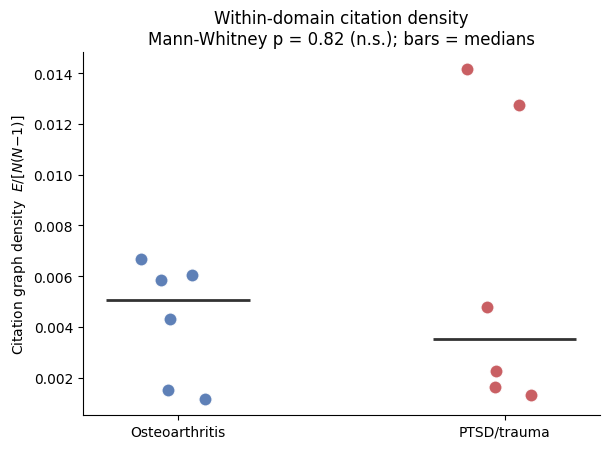

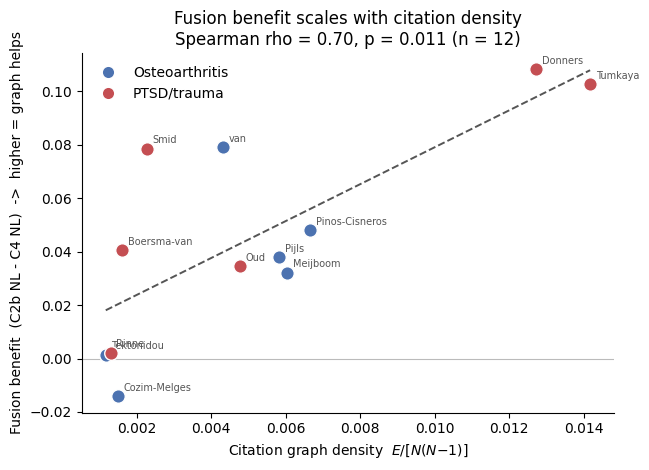

Saved Appendix C figures to /Users/belizpekkan/Library/Mobile Documents/com~apple~CloudDocs/2 AREAS/university/Master/Thesis/Week 5 - Final Results


In [22]:
# --- Appendix C figures ---
COL = {'Osteoarthritis':'#4C72B0', 'PTSD/trauma':'#C44E52'}

# Fig C.1  density by domain
fig, ax = plt.subplots(figsize=(6.2, 4.6))
for i, (dom, vals) in enumerate([('Osteoarthritis', oa), ('PTSD/trauma', pt)]):
    x = np.random.RandomState(1).normal(i, 0.05, len(vals))
    ax.scatter(x, vals, s=90, color=COL[dom], edgecolor='white', linewidth=1, zorder=3, alpha=.9)
    ax.hlines(np.median(vals), i-0.22, i+0.22, color='#333', linewidth=2, zorder=4)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Osteoarthritis', 'PTSD/trauma'])
ax.set_ylabel('Citation graph density  $E/[N(N{-}1)]$')
ax.set_title(f'Within-domain citation density\nMann-Whitney p = {p_dom:.2f} (n.s.); bars = medians')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(WEEK5/"fig_appendixC_density_by_domain.png", dpi=200, bbox_inches='tight'); plt.show()

# Fig C.2  fusion benefit vs density (headline)
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(6.6, 4.8))
for r in cdens:
    ax.scatter(r['density'], r['fusion_benefit'], s=95, color=COL[r['domain']], edgecolor='white', linewidth=1, zorder=3)
    ax.annotate(r['dataset'].split('_')[0], (r['density'], r['fusion_benefit']),
                xytext=(4, 4), textcoords='offset points', fontsize=7, color='#555')
b, a = np.polyfit(dens, [r['fusion_benefit'] for r in cdens], 1)
xs = np.linspace(min(dens), max(dens), 50)
ax.plot(xs, b*xs+a, '--', color='#555', linewidth=1.4, zorder=2)
ax.axhline(0, color='#bbb', linewidth=.8, zorder=1)
ax.set_xlabel('Citation graph density  $E/[N(N{-}1)]$')
ax.set_ylabel('Fusion benefit  (C2b NL - C4 NL)  ->  higher = graph helps')
ax.set_title(f'Fusion benefit scales with citation density\nSpearman rho = {rFB:.2f}, p = {pFB:.3f} (n = 12)')
ax.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=COL[d],markersize=9,label=d) for d in COL],
          frameon=False, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(WEEK5/"fig_appendixC_density_vs_fusion.png", dpi=200, bbox_inches='tight'); plt.show()
print("Saved Appendix C figures to", WEEK5)


### C.3  Connectivity / fragmentation (does graph structure explain C3?)

Largest-connected-component fraction (LCC) and isolated-node fraction on the relevant-paper
subgraph, plus their correlation with C3 GAT-only NL. Result: PTSD subgraphs are marginally
less fragmented (LCC p = 0.064) but **no** structural metric predicts C3 (all |rho| <= 0.08).

In [23]:
# --- C.3  connectivity of the relevant subgraph + correlation with C3 ---
def connectivity_row(ds):
    rr = list(csv.reader(open(WEEK4/"data"/f"{ds}.csv")))
    h = rr[0]; oi=h.index('openalex_id'); ri=h.index('referenced_works'); li=h.index('label_included')
    lab = {}
    for r in rr[1:]:
        n = wid(r[oi])
        if n: lab[n] = int(float(r[li])) if r[li] not in ('','nan') else 0
    G = nx.DiGraph(); G.add_nodes_from(lab)
    for r in rr[1:]:
        u = wid(r[oi])
        if u is None: continue
        for v in wids(r[ri]):
            if v in lab and v != u: G.add_edge(u, v)
    rel = [n for n in G if lab[n] == 1]
    Gr = G.subgraph(rel).to_undirected()
    comps = sorted(nx.connected_components(Gr), key=len, reverse=True)
    lcc = len(comps[0])/len(rel) if rel else float('nan')
    iso = sum(1 for n in Gr if Gr.degree(n) == 0)/len(rel) if rel else float('nan')
    return dict(density=nx.density(G), lcc=lcc, iso=iso, ncomp=len(comps))

for r in cdens:                       # cdens built in C.1 above; attach connectivity
    r.update(connectivity_row(r['dataset']))

print(f"{'domain':16}{'dataset':22}{'density':>9}{'LCC':>6}{'iso':>6}{'#comp':>7}{'C3_nl':>7}")
for r in sorted(cdens, key=lambda x: x['lcc']):
    print(f"{r['domain']:16}{r['dataset']:22}{r['density']:>9.5f}{r['lcc']:>6.2f}{r['iso']:>6.2f}{r['ncomp']:>7}{r['C3_nl']:>7.3f}")

print("\nmetric        OA_mean  PTSD_mean   MWU_p   corr_with_C3 (rho, p)")
for met in ['density','lcc','iso']:
    oa=[r[met] for r in cdens if r['domain']=='Osteoarthritis']
    pt=[r[met] for r in cdens if r['domain']=='PTSD/trauma']
    U,pm=mannwhitneyu(pt,oa,alternative='two-sided')
    rc,pc=spearmanr([r[met] for r in cdens],[r['C3_nl'] for r in cdens])
    print(f"{met:12}{np.mean(oa):>9.4f}{np.mean(pt):>10.4f}{pm:>8.3f}    rho={rc:+.2f} p={pc:.2f}")


domain          dataset                 density   LCC   iso  #comp  C3_nl
Osteoarthritis  Pinos-Cisneros_2023     0.00667  0.59  0.28     19  0.385
Osteoarthritis  Cozim-Melges_2024       0.00151  0.65  0.25     92  0.469
PTSD/trauma     Rinne_2021              0.00131  0.67  0.29    125  0.384
Osteoarthritis  Meijboom_2021           0.00605  0.81  0.19      8  0.238
Osteoarthritis  van_der_Valk_2021       0.00432  0.88  0.12     12  0.207
PTSD/trauma     Smid_2019               0.00227  0.89  0.11      4  0.303
Osteoarthritis  Pijls_2018              0.00583  0.90  0.10      6  0.577
Osteoarthritis  Tektonidou_2019         0.00117  0.92  0.06     13  0.331
PTSD/trauma     Boersma-van_Dam_2024    0.00162  0.95  0.05      6  0.228
PTSD/trauma     Oud_2018                0.00477  1.00  0.00      1  0.501
PTSD/trauma     Donners_2021            0.01273  1.00  0.00      1  0.171
PTSD/trauma     Tumkaya_2018            0.01417  1.00  0.00      1  0.401

metric        OA_mean  PTSD_mean   MW